# StockPati floorsheet: EDA

## 1. Dataset card

| Item | What I know |
|---|---|
| Source | Local `data/stockpati_floorsheet_full.csv`; [StockPati market site](https://stockpati.com/) describes its NEPSE floorsheet analytics, and [NEPSE's floorsheet page](https://www.nepalstock.com/floor-sheet) identifies the underlying exchange record. |
| Licence | **Not stated for this local CSV.** I have not found a licence or redistribution permission attached to the file. |
| Size | 2,726,159,734 bytes (about 2.54 GiB) on disk. |
| Samples | 17,539,305 transaction rows, 11 columns, 454 symbols, 215 trading dates. |
| Collection | The rows appear to be a StockPati-compiled NEPSE floorsheet export, one matched trade per row. The exact scraping/export procedure and capture date are not documented with this file, so I cannot verify them. |
| Coverage | 2025-07-17 through 2026-07-22, about one year rather than two. |
| Known limits | No clock-time timestamp; transaction-derived last price differs from published close for some stocks; occasional volume differences; unadjusted prices; no confirmed corporate-action, correction, or complete exchange-holiday metadata. |


## 2. Load the CSV, inspect structure, and show five random trades

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import polars as pl

In [2]:

df = pd.read_csv('data/stockpati_floorsheet_full.csv')
print('Shape:', df.shape, "\n")
print('Columns and dtypes:')
print(df.dtypes.to_string(), "\n")
print('Five random trades (seed=42):')
print(df.sample(n=5, random_state=42).to_string(index=False))

Shape: (17539305, 11) 

Columns and dtypes:
date                   object
symbol                 object
company_name           object
contract_no             int64
buyer_broker_code       int64
buyer_broker_name      object
seller_broker_code      int64
seller_broker_name     object
quantity                int64
rate                  float64
amount                float64 

Five random trades (seed=42):
      date symbol                         company_name      contract_no  buyer_broker_code                          buyer_broker_name  seller_broker_code          seller_broker_name  quantity  rate    amount
2026-07-01   UPCL      Universal Power Company Limited 2026070104000625                 38 Dipshikha Dhitopatra Karobar Co. Pvt. Ltd.                  42    Sani Securities Co. Ltd.       150 348.0   52200.0
2026-05-13   NHPC National Hydro Power Company Limited 2026051304005120                 58                  Naasa Securities Co. Ltd.                  78   Garima Securities Limi

## 3. Missing, duplicate, and corrupt entries

I count missing or blank fields, exact duplicate rows, invalid dates, nonpositive trade values, and amount arithmetic mismatches. I would review duplicate contract numbers before removal and correct invalid entries from the source where possible; otherwise I would exclude them. Shared symbol, broker, rate, and date do not alone make two trades duplicates.

In [3]:

blank_text = sum(df[c].astype('string').str.strip().eq('').sum()
                 for c in ['date', 'symbol', 'company_name',
                           'buyer_broker_name', 'seller_broker_name'])
parsed_date = pd.to_datetime(df['date'], errors='coerce')
amount_error = (df['amount'] - df['quantity'] * df['rate']).abs()
quality_counts = pd.Series({
    'rows': len(df),
    'missing_cells': int(df.isna().sum().sum()),
    'rows_with_missing_cells': int(df.isna().any(axis=1).sum()),
    'blank_text_cells': int(blank_text),
    'exact_duplicate_rows': int(df.duplicated().sum()),
    'invalid_dates': int(parsed_date.isna().sum()),
    'nonpositive_quantity': int((df['quantity'] <= 0).sum()),
    'nonpositive_rate': int((df['rate'] <= 0).sum()),
    'nonpositive_amount': int((df['amount'] <= 0).sum()),
    'amount_mismatch_gt_1_paisa': int((amount_error > 0.011).sum()),
})
print(quality_counts.to_string())

rows                          17539305
missing_cells                        0
rows_with_missing_cells              0
blank_text_cells                     0
exact_duplicate_rows                 0
invalid_dates                        0
nonpositive_quantity                 0
nonpositive_rate                     0
nonpositive_amount                   0
amount_mismatch_gt_1_paisa           0


I found **0 missing cells, 0 blank text cells, 0 exact duplicate rows, and 0 entries failing the date, positive-value, or amount-arithmetic checks** in 17,539,305 trades. I therefore keep all rows under these structural rules; no imputation or deduplication is needed. This does not prove every source trade is authentic or account for later exchange corrections.

## 4. Class or target distribution

I use a **provisional** three-class target from each stock's next observed trading session. BUY means its transaction-derived last price rises by **more than 1%**; SELL means it falls by **more than 1%**; HOLD covers returns from -1% to +1%, inclusive. I compute this from the CSV alone and leave the last row per stock unlabeled. I give the exact formula again in step 11. The chart counts labeled stock-days, not individual transactions.

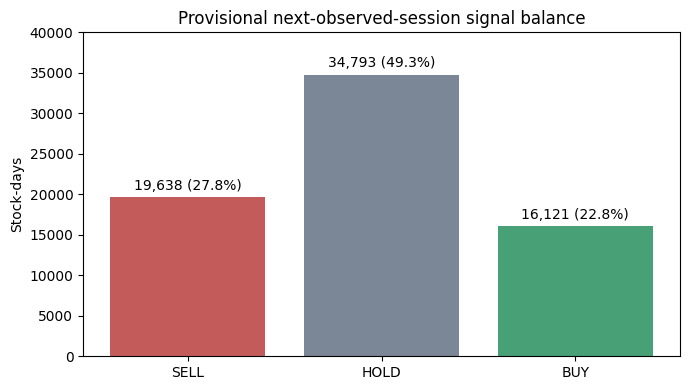

Label counts: {'SELL': 19638, 'HOLD': 34793, 'BUY': 16121}
Unlabeled final stock-days: 454


In [ ]:
trades = pl.scan_csv(
    'data/stockpati_floorsheet_full.csv',
    try_parse_dates=True,
    schema_overrides={'contract_no': pl.Int64},
)
daily_close = (trades.group_by(['symbol','date']).agg(
    pl.col('rate').sort_by('contract_no').last().alias('last_trade_close')
).collect().sort(['symbol','date']))
labelled_daily = (daily_close
    .with_columns(
        pl.col('last_trade_close').shift(-1).over('symbol').alias('next_last_trade_close'),
        pl.col('date').shift(-1).over('symbol').alias('next_trade_date'),
    )
    .with_columns((pl.col('next_last_trade_close')/pl.col('last_trade_close')-1).alias('next_return'))
    .with_columns(pl.when(pl.col('next_return').is_null()).then(None)
       .when(pl.col('next_return') > .01).then(pl.lit('BUY'))
       .when(pl.col('next_return') < -.01).then(pl.lit('SELL'))
       .otherwise(pl.lit('HOLD')).alias('signal')))
counts = labelled_daily.group_by('signal').len()
balance = {row['signal']: row['len'] for row in counts.to_dicts()}
order = ['SELL','HOLD','BUY']
values = [balance.get(k,0) for k in order]
fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(order, values, color=['#c45b5b','#7b8796','#48a176'])
ax.bar_label(bars, labels=[f'{v:,} ({v/sum(values):.1%})' for v in values], padding=3)
ax.set(ylabel='Stock-days', title='Provisional next-observed-session signal balance',
       ylim=(0,max(values)*1.15))
fig.tight_layout()
plt.show()
print('Label counts:', dict(zip(order, values)))
print('Unlabeled final stock-days:', balance.get(None, 0))

HOLD is the largest class: **34,793 (49.3%)**, compared with **19,638 SELL (27.8%)** and **16,121 BUY (22.8%)**. An LSTM optimized only for accuracy could overpredict HOLD and miss BUY/SELL moves. I will derive any class weights from training dates only and assess macro F1, balanced accuracy, and per-class precision/recall against an always-HOLD baseline. These provisional labels depend on transaction-derived last prices, not authenticated published closes.

## 5. Train / validation / test split plan

I will use a **global time split**, not a random or stratified row split: earliest 70% of trading dates for training, next 15% for validation, final 15% for test. All stocks on a date stay together because they share market conditions. Each LSTM input sequence stays within one stock and uses only information known by its prediction date. I exclude an earlier-partition row if its label depends on a price in the next partition. I fit scaling and class weights on training data only, choose hyperparameters on validation, and reserve test for one final assessment. A stock-held-out split would instead test generalization to entirely unseen symbols.

In [5]:
dates = daily_close['date'].unique().sort().to_list()
train_cut = dates[int(len(dates) * .70)]
test_cut = dates[int(len(dates) * .85)]
train_rows = labelled_daily.filter(
    (pl.col('date') < train_cut) & (pl.col('next_trade_date') < train_cut)
    & pl.col('signal').is_not_null())
validation_rows = labelled_daily.filter(
    (pl.col('date') >= train_cut) & (pl.col('date') < test_cut)
    & (pl.col('next_trade_date') < test_cut) & pl.col('signal').is_not_null())
test_rows = labelled_daily.filter(
    (pl.col('date') >= test_cut) & pl.col('signal').is_not_null())
print('Train: before', train_cut, '| validation:', train_cut,
      'to before', test_cut, '| test: from', test_cut)
print('Labeled stock-days after boundary purge:',
      {'train':train_rows.height,'validation':validation_rows.height,'test':test_rows.height})

Train: before 2026-04-01 | validation: 2026-04-01 to before 2026-05-27 | test: from 2026-05-27
Labeled stock-days after boundary purge: {'train': 48089, 'validation': 10470, 'test': 11182}


## 6. Three findings that change my LSTM design

1. **Thin stock-days:** 15,065 of 71,006 stock-days (21.2%) have fewer than 20 trades, and 2,917 have only one. I will flag low-support days and evaluate performance separately there because intraday summaries from one trade are unstable.
2. **Uneven stock participation:** the ten busiest symbols contribute 16.6% of transactions. I will build one daily sequence per stock rather than one sequence per trade, so highly traded stocks do not dominate only through row count.
3. **Changing market activity:** daily trades range from 4,051 to 205,611, and reported circuit days are among the quietest. I will use robust, relative features and a forward-time test to check whether the LSTM survives different market regimes instead of learning the level of market activity alone.

## 7. Aggregate transactions to daily OHLCV per stock

I aggregate each `(symbol, date)` to a daily row. I order trades by `contract_no` for the first and final transaction rates, take the highest and lowest rates, sum share quantity for volume, and count trades. I call the final rate **last-trade close** because the published NEPSE close can use a different calculation. The contract number supplies ordering, not an intraday clock time. I keep turnover and VWAP as checks. These are unadjusted transaction prices; corporate actions require separate adjustment data.

In [ ]:
daily_ohlcv = (trades.group_by(['symbol', 'date']).agg(
    pl.col('rate').sort_by('contract_no').first().alias('open'),
    pl.col('rate').max().alias('high'),
    pl.col('rate').min().alias('low'),
    pl.col('rate').sort_by('contract_no').last().alias('last_trade_close'),
    pl.col('quantity').sum().alias('volume'),
    pl.col('amount').sum().alias('turnover'),
    pl.len().alias('trade_count'),
).with_columns((pl.col('turnover') / pl.col('volume')).alias('vwap'))
 .collect().sort(['symbol', 'date']))
print('Daily stock rows:', daily_ohlcv.height)
print('Range:', daily_ohlcv['date'].min(), 'to', daily_ohlcv['date'].max())
print(daily_ohlcv.filter(
    (pl.col('date') == pl.date(2025, 7, 17))
    & pl.col('symbol').is_in(['BBC', 'HBL', 'SHIVM'])
).select(['symbol','open','high','low','last_trade_close','volume','trade_count']).to_dicts())

Daily stock rows: 71006
Range: 2025-07-17 to 2026-07-22
[{'symbol': 'BBC', 'open': 5410.0, 'high': 5480.0, 'low': 5400.1, 'last_trade_close': 5480.0, 'volume': 819, 'trade_count': 51}, {'symbol': 'HBL', 'open': 241.0, 'high': 261.0, 'low': 236.0, 'last_trade_close': 249.0, 'volume': 407528, 'trade_count': 1088}, {'symbol': 'SHIVM', 'open': 542.0, 'high': 570.0, 'low': 542.0, 'last_trade_close': 568.9, 'volume': 568742, 'trade_count': 2447}]


### Published-price spot check

I compared three stocks on **2025-07-17** with the [published unadjusted NEPSE daily-price CSV](https://github.com/socrateai-official/nepse-open-data/blob/main/ohlc_unadjusted_stock/unadj_2025-07-17.csv). This is an independently published NEPSE dataset, not an authenticated exchange export. Its repository describes the [unadjusted OHLC files](https://github.com/socrateai-official/nepse-open-data). I record the reference values below so this notebook remains runnable without a network request. The comparison verifies some fields and surfaces discrepancies; I do not silently replace floorsheet values.

In [7]:
published_sample = pl.DataFrame({
    'symbol': ['BBC', 'HBL', 'SHIVM'],
    'published_open': [5410.0, 241.0, 542.0],
    'published_high': [5480.0, 261.0, 570.0],
    'published_low': [5400.1, 236.0, 542.0],
    'published_close': [5471.17, 248.56, 567.29],
    'published_volume': [819, 407510, 568683],
})
spot = (daily_ohlcv.filter(pl.col('date') == pl.date(2025, 7, 17))
        .join(published_sample, on='symbol', how='inner')
        .select('symbol','open','published_open','high','published_high',
                'low','published_low','last_trade_close','published_close',
                'volume','published_volume')
        .sort('symbol'))
print(spot.to_dicts())
print('Exact open/high/low matches:',
      spot.select([(pl.col(a) == pl.col('published_'+a)).sum().alias(a)
                   for a in ['open','high','low']]).to_dicts())
print('Volume differences:', spot.select(
    'symbol', (pl.col('volume')-pl.col('published_volume')).alias('shares')
).to_dicts())

[{'symbol': 'BBC', 'open': 5410.0, 'published_open': 5410.0, 'high': 5480.0, 'published_high': 5480.0, 'low': 5400.1, 'published_low': 5400.1, 'last_trade_close': 5480.0, 'published_close': 5471.17, 'volume': 819, 'published_volume': 819}, {'symbol': 'HBL', 'open': 241.0, 'published_open': 241.0, 'high': 261.0, 'published_high': 261.0, 'low': 236.0, 'published_low': 236.0, 'last_trade_close': 249.0, 'published_close': 248.56, 'volume': 407528, 'published_volume': 407510}, {'symbol': 'SHIVM', 'open': 542.0, 'published_open': 542.0, 'high': 570.0, 'published_high': 570.0, 'low': 542.0, 'published_low': 542.0, 'last_trade_close': 568.9, 'published_close': 567.29, 'volume': 568742, 'published_volume': 568683}]
Exact open/high/low matches: [{'open': 3, 'high': 3, 'low': 3}]
Volume differences: [{'symbol': 'BBC', 'shares': 0}, {'symbol': 'HBL', 'shares': 18}, {'symbol': 'SHIVM', 'shares': 59}]


I found exact open, high, and low matches for all three examples. The floorsheet final-trade rates differ from all three published closes; BBC volume matches, while HBL and SHIVM differ by 18 and 59 shares. I will use the floorsheet-derived series only as a **proxy** for close and will not claim it reproduces official close/volume exactly. Before a production price model, I would obtain exchange-authenticated daily prices and reconcile canceled/corrected trades and the exchange close methodology.

## 8. Trades, volume, and active stocks per day; holidays and circuits

My CSV spans **2025-07-17 to 2026-07-22**, so it does **not** contain two years. I plot every calendar date in that available span; zero bars on missing dates mean no transactions in this file and do not by themselves prove a holiday. I mark the selected 2025 Dashain and Tihar public-holiday windows, which also contain no rows in the CSV, using the [Nepal public-holiday list](https://pradhanlaw.com/publications/list-of-public-holidays-2082-bs-202526-ad). I mark **2025-09-18** and **2026-03-09** as reported exchange-wide circuit-breaker days using [Kathmandu Post coverage](https://kathmandupost.com/money/2025/09/18/nepse-plunges-160-points-trading-halted) and [Kathmandu Post coverage](https://kathmandupost.com/money/2026/03/09/nepse-closes-after-three-circuit-breakers-triggered-by-6-percent-surge). These holiday marks are not a complete exchange calendar. I do not infer any other circuit days from price moves alone.

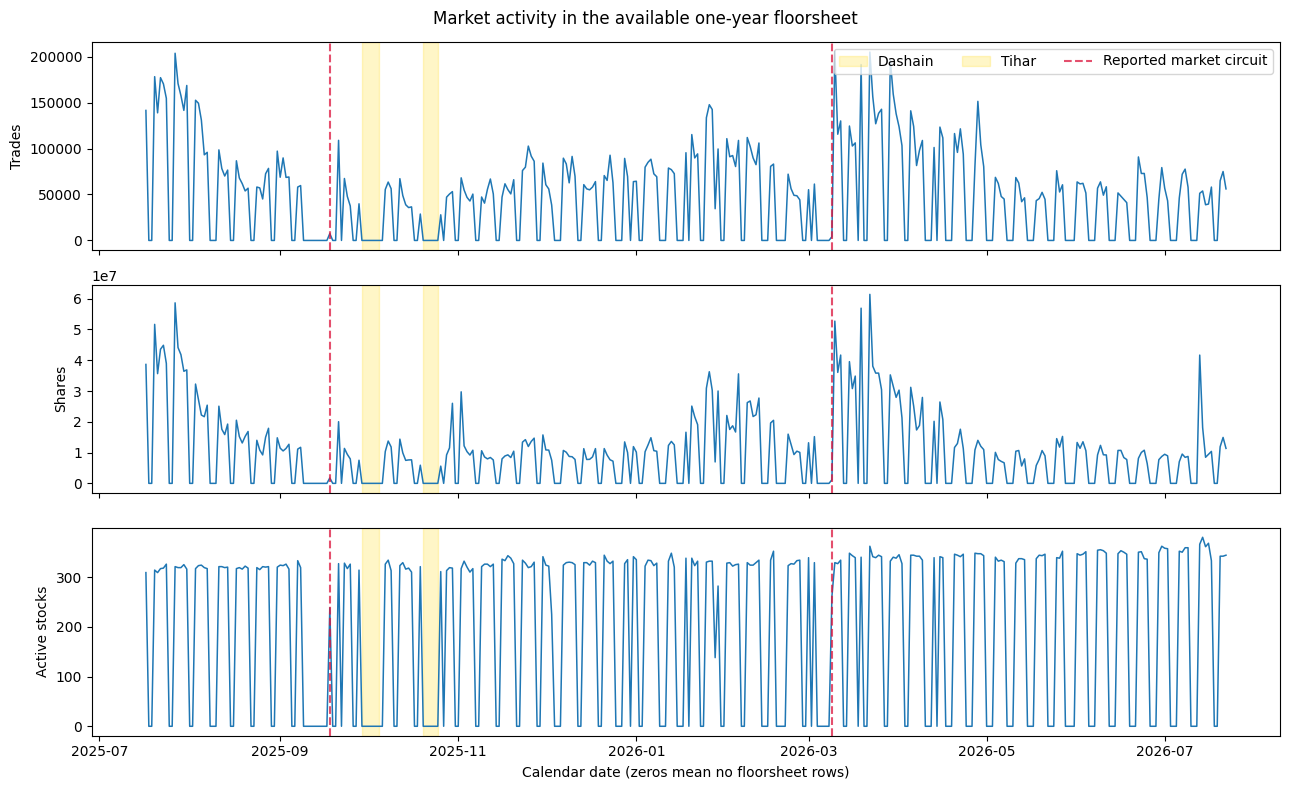

Trading dates: 215 | calendar range: 2025-07-17 to 2026-07-22
Reported circuit-day activity: {datetime.date(2025, 9, 18): {'trades': 7435, 'volume': 1752781, 'active_stocks': 238}, datetime.date(2026, 3, 9): {'trades': 4051, 'volume': 1143767, 'active_stocks': 261}}


In [ ]:
market_daily = (daily_ohlcv.group_by('date').agg(
    pl.col('trade_count').sum().alias('trades'),
    pl.col('volume').sum().alias('volume'),
    pl.len().alias('active_stocks'),
).sort('date').to_dicts())
market_daily = pd.DataFrame(market_daily).set_index('date')
calendar = pd.date_range(market_daily.index.min(), market_daily.index.max(), freq='D')
market_calendar = market_daily.reindex(calendar, fill_value=0)
holidays = [
    (pd.Timestamp('2025-09-29'), pd.Timestamp('2025-10-04'), 'Dashain'),
    (pd.Timestamp('2025-10-20'), pd.Timestamp('2025-10-24'), 'Tihar'),
]
circuits = [pd.Timestamp('2025-09-18'), pd.Timestamp('2026-03-09')]
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax, col, ylabel in zip(axes, ['trades','volume','active_stocks'],
                            ['Trades', 'Shares', 'Active stocks']):
    ax.plot(market_calendar.index, market_calendar[col], lw=1.1)
    ax.set_ylabel(ylabel)
    for start, end, name in holidays:
        ax.axvspan(start, end + pd.Timedelta(days=1), color='gold', alpha=.22,
                   label=name if ax is axes[0] else None)
    for date in circuits:
        ax.axvline(date, color='crimson', linestyle='--', alpha=.75,
                   label='Reported market circuit' if ax is axes[0] and date == circuits[0] else None)
axes[0].legend(loc='upper right', ncol=3)
axes[-1].set_xlabel('Calendar date (zeros mean no floorsheet rows)')
fig.suptitle('Market activity in the available one-year floorsheet')
fig.tight_layout()
plt.show()
print('Trading dates:', len(market_daily),
      '| calendar range:', calendar.min().date(), 'to', calendar.max().date())
print('Reported circuit-day activity:', market_daily.loc[circuits].to_dict('index'))

## 9. Intraday trade count and volume by time of day

I cannot calculate trade count or volume by hour from this file: its columns contain a **date** and a **contract number**, but no trade timestamp or time-of-day field. A contract number gives sequence, not clock time. I therefore leave the requested intraday distribution unavailable until timestamped trades are supplied. I will not derive fake times from contract numbers.

In [9]:
print('Columns:', df.columns.to_list())
print('Timestamp/time-of-day columns:',
      [c for c in df.columns if any(k in c.lower() for k in
       ('timestamp', 'trade_time', 'execution_time', 'time_of_day'))])

Columns: ['date', 'symbol', 'company_name', 'contract_no', 'buyer_broker_code', 'buyer_broker_name', 'seller_broker_code', 'seller_broker_name', 'quantity', 'rate', 'amount']
Timestamp/time-of-day columns: []


## 10. Broker activity and concentration

I count shares on the buyer and seller side separately; every trade contributes its quantity to one buyer and one seller. For each stock, I measure the largest buyer-broker share of its total bought volume and the buyer-side Herfindahl index (sum of squared broker shares). These are descriptive concentration measures, not proof of manipulation. I examine low-volume symbols separately because one or two trades can mechanically produce 100% concentration.

In [10]:
buyer_volume = (trades.group_by(['buyer_broker_code','buyer_broker_name'])
                .agg(pl.col('quantity').sum().alias('bought_shares'))
                .sort('bought_shares', descending=True).collect())
seller_volume = (trades.group_by(['seller_broker_code','seller_broker_name'])
                 .agg(pl.col('quantity').sum().alias('sold_shares'))
                 .sort('sold_shares', descending=True).collect())
print('Top buyer brokers:', buyer_volume.head(5).to_dicts())
print('Top seller brokers:', seller_volume.head(5).to_dicts())

stock_buyer = (trades.group_by(['symbol','buyer_broker_code'])
               .agg(pl.col('quantity').sum().alias('broker_shares')).collect())
stock_concentration = (stock_buyer.group_by('symbol').agg(
    pl.col('broker_shares').sum().alias('stock_volume'),
    (pl.col('broker_shares').max()/pl.col('broker_shares').sum()).alias('top_buyer_share'),
    ((pl.col('broker_shares')/pl.col('broker_shares').sum())**2).sum().alias('buyer_hhi'),
    pl.len().alias('buyer_brokers'),
).sort('symbol'))
print('Median top-buyer share:', round(stock_concentration['top_buyer_share'].median(), 3))
print('Most concentrated stocks with >=100,000 bought shares:',
      stock_concentration.filter(pl.col('stock_volume') >= 100_000)
      .sort('top_buyer_share', descending=True).head(5).to_dicts())

Top buyer brokers: [{'buyer_broker_code': 58, 'buyer_broker_name': 'Naasa Securities Co. Ltd.', 'bought_shares': 232051156}, {'buyer_broker_code': 34, 'buyer_broker_name': 'Vision Securities Pvt. Ltd.', 'bought_shares': 172231068}, {'buyer_broker_code': 42, 'buyer_broker_name': 'Sani Securities Co. Ltd.', 'bought_shares': 145188859}, {'buyer_broker_code': 49, 'buyer_broker_name': 'Online Securities Pvt. Ltd.', 'bought_shares': 130794120}, {'buyer_broker_code': 44, 'buyer_broker_name': 'Dynamic Money Managers Securities Pvt. Ltd.', 'bought_shares': 116199386}]
Top seller brokers: [{'seller_broker_code': 58, 'seller_broker_name': 'Naasa Securities Co. Ltd.', 'sold_shares': 242658444}, {'seller_broker_code': 34, 'seller_broker_name': 'Vision Securities Pvt. Ltd.', 'sold_shares': 157288769}, {'seller_broker_code': 49, 'seller_broker_name': 'Online Securities Pvt. Ltd.', 'sold_shares': 130950842}, {'seller_broker_code': 48, 'seller_broker_name': 'Trishakti Securities Public Limited', 'sold_

## 11. Exact signal definition and class balance

For stock `s` on date `t`, I define the supervised target as `r(s,t) = last_trade_close(s, next observed stock session) / last_trade_close(s,t) - 1`. The label is **BUY** if `r > 0.01`, **SELL** if `r < -0.01`, and **HOLD** if `-0.01 <= r <= 0.01`. This is the stock's next **observed** trading session, not necessarily the exchange's next trading day. I leave the last observed day of each stock unlabeled. I chose the 1% threshold for this exploratory analysis; I have not optimized it. The floorsheet's final trade price differs from some published closing prices, so I will reconcile official closes and corporate actions before relying on this signal for a trading model.

The class balance is **19,638 SELL (27.8%)**, **34,793 HOLD (49.3%)**, and **16,121 BUY (22.8%)** among 70,552 labeled stock-days; **454** final stock-days have no label. HOLD is nearly half the sample and more than twice as common as BUY. If I optimize overall accuracy alone, my LSTM may favor HOLD and miss actionable moves. I will calculate class weights from training data only, compare with an always-HOLD baseline, and report macro F1, balanced accuracy, per-class precision and recall, and a confusion matrix on the chronological test set. I will never use future prices or the label as model inputs.

In [11]:
class_balance = pl.DataFrame({
    'signal': ['SELL', 'HOLD', 'BUY'],
    'stock_days': [balance['SELL'], balance['HOLD'], balance['BUY']],
}).with_columns((100 * pl.col('stock_days') / sum(values)).round(1).alias('percent'))
print(class_balance.to_dicts())

[{'signal': 'SELL', 'stock_days': 19638, 'percent': 27.8}, {'signal': 'HOLD', 'stock_days': 34793, 'percent': 49.3}, {'signal': 'BUY', 'stock_days': 16121, 'percent': 22.8}]


## 12. CNN experiment: next-observed-session classification

This implementation adapts the supplied **FashionMNIST CNN** to the week-2
StockPati floorsheet dataset. The earlier EDA proposed an LSTM; this experiment
instead uses the CNN required by this assignment. A **1D convolution across 20
observed stock sessions** replaces image convolution. The shared structure is
two convolution–ReLU–pool blocks, flatten, dropout, a linear classifier, Adam,
and cross-entropy. There are three output classes rather than ten.

**Run sections 12–18 independently** (the earlier full-CSV pandas EDA is not
required). Dependencies: Python, numpy, pandas, polars, matplotlib,
scikit-learn, and PyTorch. Run from the notebook's folder. Outputs go to
`cnn_results/`. The full source CSV is aggregated without loading all trade
columns into pandas. The daily cache is invalidated by CSV size and modification time.

The prediction is made after the final observed trade of a session. SELL means
next observed session return < -1%; BUY means > +1%; HOLD includes both boundaries.
These are experimental class names, not validated trading recommendations.

In [1]:
from pathlib import Path
import copy, json, random, platform
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score, f1_score)

OUT = Path('cnn_results')
OUT.mkdir(exist_ok=True)
SEED = 42
CLASSES = ['SELL', 'HOLD', 'BUY']
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_num_threads(min(4, torch.get_num_threads()))
def seed_all():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_all()
print('Device:', DEVICE, '| PyTorch:', torch.__version__)
source = Path('data/stockpati_floorsheet_full.csv')
signature = {'size': source.stat().st_size, 'mtime_ns': source.stat().st_mtime_ns}
cache, stamp = OUT/'daily_ohlcv.parquet', OUT/'daily_source.json'
if cache.exists() and stamp.exists() and json.loads(stamp.read_text()) == signature:
    daily = pl.read_parquet(cache)
else:
    daily = (pl.scan_csv(source, try_parse_dates=True,
                        schema_overrides={'contract_no': pl.Int64})
        .group_by(['symbol', 'date']).agg(
            pl.col('rate').sort_by('contract_no').first().alias('open'),
            pl.col('rate').max().alias('high'),
            pl.col('rate').min().alias('low'),
            pl.col('rate').sort_by('contract_no').last().alias('close'),
            pl.col('quantity').sum().alias('volume'),
            pl.col('amount').sum().alias('turnover'),
            pl.len().alias('trade_count'))
        .collect().sort(['symbol', 'date']))
    daily.write_parquet(cache)
    stamp.write_text(json.dumps(signature))
prices = pd.DataFrame(daily.to_dicts())
prices['date'] = pd.to_datetime(prices['date'])
print('Daily rows:', len(prices), '| symbols:', prices.symbol.nunique(),
      '| dates:', prices.date.nunique())

Device: cuda | PyTorch: 2.7.1+cu118
Daily rows: 71006 | symbols: 454 | dates: 215


## 13. Causal features and leakage controls

Each input has shape **[9 features, 20 sessions]**. Features are close return,
open/previous-close return, intraday range/close, close/open return,
log(1+volume), log(1+turnover), log(1+trade count), VWAP/close deviation,
and calendar-day gap since the previous observation. Absolute stock prices and
symbol IDs are excluded. No future price is an input. Gaps are measured rather
than filled with invented sessions.

Dates are split globally 70%/15%/15%. A label crossing the training or validation
boundary is purged. Windows may use historical context from the preceding
partition, which is available at prediction time. Scaling is fitted only on
the unique feature rows used by training windows; class weights use training
labels only. Windows never cross symbols. The first 20-session window also
needs a preceding price for return features, so some EDA rows are excluded.

In [2]:
WINDOW = 20
g = prices.groupby('symbol', sort=False)
prev = g['close'].shift(1)
prices['close_return'] = prices['close']/prev - 1
prices['open_return'] = prices['open']/prev - 1
prices['range_fraction'] = (prices['high']-prices['low'])/prices['close']
prices['intraday_return'] = prices['close']/prices['open'] - 1
for col in ['volume', 'turnover', 'trade_count']:
    prices['log_'+col] = np.log1p(prices[col])
prices['vwap_deviation'] = prices['turnover']/prices['volume']/prices['close'] - 1
prices['gap_days'] = g['date'].diff().dt.days
prices['next_date'] = g['date'].shift(-1)
prices['next_return'] = g['close'].shift(-1)/prices['close'] - 1
prices['target'] = np.select([prices.next_return < -.01, prices.next_return > .01], [0, 2], default=1)
FEATURES = ['close_return', 'open_return', 'range_fraction', 'intraday_return',
            'log_volume', 'log_turnover', 'log_trade_count', 'vwap_deviation', 'gap_days']
dates = np.sort(prices.date.unique())
VAL_START, TEST_START = pd.Timestamp(dates[int(len(dates)*.70)]), pd.Timestamp(dates[int(len(dates)*.85)])
raw = prices[FEATURES].to_numpy(dtype=np.float64)
indices = {'train': [], 'validation': [], 'test': []}
ends = {k: [] for k in indices}
for _, stock in prices.groupby('symbol', sort=False):
    rows = stock.index.to_numpy()
    for j in range(WINDOW-1, len(rows)):
        end = rows[j]
        r = prices.loc[end]
        window = rows[j-WINDOW+1:j+1]
        if pd.isna(r.next_date) or not np.isfinite(raw[window]).all():
            continue
        if r.date < VAL_START and r.next_date < VAL_START:
            split = 'train'
        elif VAL_START <= r.date < TEST_START and r.next_date < TEST_START:
            split = 'validation'
        elif r.date >= TEST_START:
            split = 'test'
        else:
            continue
        indices[split].append(window)
        ends[split].append(end)
assert all(len(v) for v in indices.values())
scaler = StandardScaler().fit(raw[np.unique(np.asarray(indices['train']))])
scaled = scaler.transform(raw).astype(np.float32)
X = {k: scaled[np.asarray(v)].transpose(0, 2, 1).copy() for k,v in indices.items()}
y = {k: prices.loc[ends[k], 'target'].to_numpy(dtype=np.int64) for k in ends}
assert prices.loc[ends['train'], 'next_date'].max() < VAL_START
assert prices.loc[ends['validation'], 'next_date'].max() < TEST_START
for split in indices:
    assert np.isfinite(X[split]).all()
    assert np.all(prices.symbol.to_numpy()[np.asarray(indices[split])] ==
                  prices.symbol.to_numpy()[ends[split]][:, None])
counts = np.bincount(y['train'], minlength=3)
assert np.all(counts > 0)
weights = torch.tensor(len(y['train'])/(3*counts), dtype=torch.float32, device=DEVICE)
split_table = pd.DataFrame([{'split': k, 'samples': len(y[k]),
    'first_prediction': str(prices.loc[ends[k], 'date'].min().date()),
    'last_prediction': str(prices.loc[ends[k], 'date'].max().date()),
    **dict(zip(CLASSES, np.bincount(y[k], minlength=3).tolist()))} for k in y])
print('Validation starts:', VAL_START.date(), '| test starts:', TEST_START.date())
print(split_table.to_string(index=False))
print('Training class weights:', weights.cpu().numpy())
split_table.to_csv(OUT/'split_summary.csv', index=False)

Validation starts: 2026-04-01 | test starts: 2026-05-27
     split  samples first_prediction last_prediction  SELL  HOLD  BUY
     train    40255       2025-08-17      2026-03-30 10836 20074 9345
validation    10324       2026-04-01      2026-05-25  2821  5108 2395
      test    11003       2026-05-27      2026-07-21  3028  5805 2170
Training class weights: [1.2383106  0.66844344 1.4358838 ]


## 14. CNN architecture and controlled hyperparameter experiments

With padding=1 and kernel size 3, each convolution preserves the temporal
length; pooling reduces 20 → 10 → 5. Channel widths are 32 and 64, so the
linear classifier receives 64 × 5 values. Dropout is disabled during evaluation.

Four runs use the same seed, split, features, class-weighted loss, batch size
128 and 10-epoch budget. Starting from learning rate 0.001 and dropout 0.5,
we change learning rate to 0.0003, dropout to 0.2, then both. Adam weight decay
is 0.0001. Each run keeps the epoch with the best **validation macro F1**;
the best run is chosen by that same metric. Test labels play no role in selection.
These are single-seed comparisons, not statistical evidence of superiority.

In [3]:
class StockCNN(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(len(FEATURES), 32, 3, padding=1), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool1d(2),
            nn.Flatten(), nn.Dropout(dropout), nn.Linear(64*(WINDOW//4), 3))
    def forward(self, x):
        return self.net(x)

datasets = {k: TensorDataset(torch.from_numpy(X[k]), torch.from_numpy(y[k])) for k in X}
def loader(split, shuffle=False):
    return DataLoader(datasets[split], batch_size=128, shuffle=shuffle,
                      generator=torch.Generator().manual_seed(SEED), num_workers=0)

@torch.no_grad()
def predict(model, split):
    model.eval()
    return np.concatenate([model(xb.to(DEVICE)).argmax(1).cpu().numpy()
                           for xb, _ in loader(split)])

CONFIGS = [dict(name='reference', lr=.001, dropout=.5),
           dict(name='lower_lr', lr=.0003, dropout=.5),
           dict(name='lower_dropout', lr=.001, dropout=.2),
           dict(name='both_changes', lr=.0003, dropout=.2)]
EPOCHS = 10
history, results, states = [], [], {}
print(StockCNN())
for cfg in CONFIGS:
    seed_all()
    model = StockCNN(cfg['dropout']).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=.0001)
    loss_fn = nn.CrossEntropyLoss(weight=weights, reduction='none')
    train_loader = loader('train', shuffle=True)
    best_score, best_epoch = -1., 0
    for epoch in range(1, EPOCHS+1):
        model.train()
        loss_sum, weight_sum, correct = 0., 0., 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss_values = loss_fn(logits, yb)
            denominator = weights[yb].sum()
            loss = loss_values.sum()/denominator
            loss.backward()
            optimizer.step()
            loss_sum += loss_values.sum().item()
            weight_sum += denominator.item()
            correct += (logits.argmax(1) == yb).sum().item()
        vp = predict(model, 'validation')
        score = f1_score(y['validation'], vp, labels=[0,1,2], average='macro', zero_division=0)
        history.append(dict(run=cfg['name'], epoch=epoch, train_loss=loss_sum/weight_sum,
                            train_accuracy=correct/len(y['train']),
                            val_accuracy=accuracy_score(y['validation'], vp), val_macro_f1=score))
        if score > best_score:
            best_score, best_epoch = score, epoch
            states[cfg['name']] = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
        print(f"{cfg['name']:14s} epoch {epoch:2d}: loss={loss_sum/weight_sum:.4f}, validation F1={score:.4f}", flush=True)
    results.append({**cfg, 'batch_size': 128, 'epochs': EPOCHS,
                    'best_epoch': best_epoch, 'val_macro_f1': best_score})
experiments = pd.DataFrame(results).sort_values('val_macro_f1', ascending=False, kind='stable')
history = pd.DataFrame(history)
experiments.to_csv(OUT/'experiments.csv', index=False)
history.to_csv(OUT/'training_history.csv', index=False)
winner = experiments.iloc[0].to_dict()
model = StockCNN(winner['dropout']).to(DEVICE)
model.load_state_dict(states[winner['name']])
print('Validation-selected experiments:')
print(experiments.to_string(index=False))

StockCNN(
  (net): Sequential(
    (0): Conv1d(9, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=320, out_features=3, bias=True)
  )
)
reference      epoch  1: loss=1.0647, validation F1=0.3782
reference      epoch  2: loss=1.0155, validation F1=0.3716
reference      epoch  3: loss=0.9899, validation F1=0.4038
reference      epoch  4: loss=0.9743, validation F1=0.3769
reference      epoch  5: loss=0.9633, validation F1=0.3857
reference      epoch  6: loss=0.9545, validation F1=0.3797
reference      epoch  7: loss=0.9476, validation F1=0.3815
reference      epoch  8: loss=0.9372, validation F1=0.3447
reference    

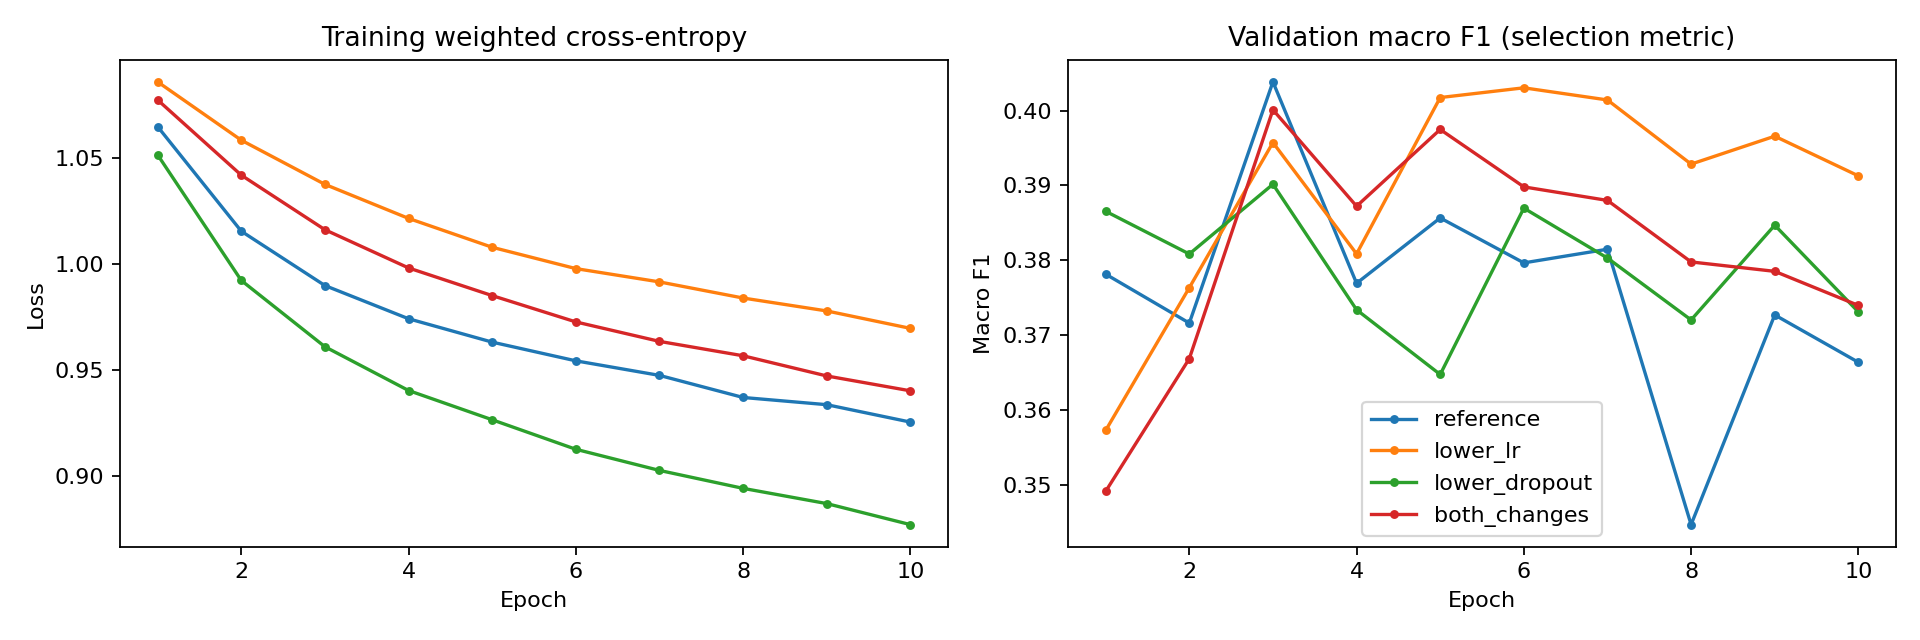

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, h in history.groupby('run', sort=False):
    axes[0].plot(h.epoch, h.train_loss, marker='.', label=name)
    axes[1].plot(h.epoch, h.val_macro_f1, marker='.', label=name)
axes[0].set(title='Training weighted cross-entropy', xlabel='Epoch', ylabel='Loss')
axes[1].set(title='Validation macro F1 (selection metric)', xlabel='Epoch', ylabel='Macro F1')
axes[1].legend()
fig.tight_layout()
fig.savefig(OUT/'learning_curves.png', dpi=160)
plt.show()

## 15. Final held-out classifier evaluation

Evaluate the validation-selected checkpoint once on the final date block.
Precision measures how often a predicted class is correct; recall measures
how many actual members of that class are recovered. F-score here means
**F1 = 2 × precision × recall / (precision + recall)**. Macro F1 averages
equally across classes; weighted F1 weights by support. Undefined precision
or recall is reported as zero. Matrix rows are actual classes, columns predicted.
The always-HOLD baseline uses the same test samples. Its zero recall on SELL
and BUY demonstrates why accuracy alone is insufficient.

              precision    recall  f1-score       support
SELL           0.387402  0.392008  0.389691   3028.000000
HOLD           0.620214  0.580362  0.599626   5805.000000
BUY            0.297168  0.343318  0.318580   2170.000000
accuracy       0.481778  0.481778  0.481778      0.481778
macro avg      0.434928  0.438563  0.435966  11003.000000
weighted avg   0.492434  0.481778  0.486425  11003.000000

      model  accuracy  balanced_accuracy  macro_f1  weighted_f1
        CNN  0.481778           0.438563  0.435966     0.486425
Always HOLD  0.527583           0.333333  0.230248     0.364424

Liquidity diagnostics:
               slice  samples  macro_f1
Fewer than 20 trades     2710  0.423669
  At least 20 trades     8293  0.417690

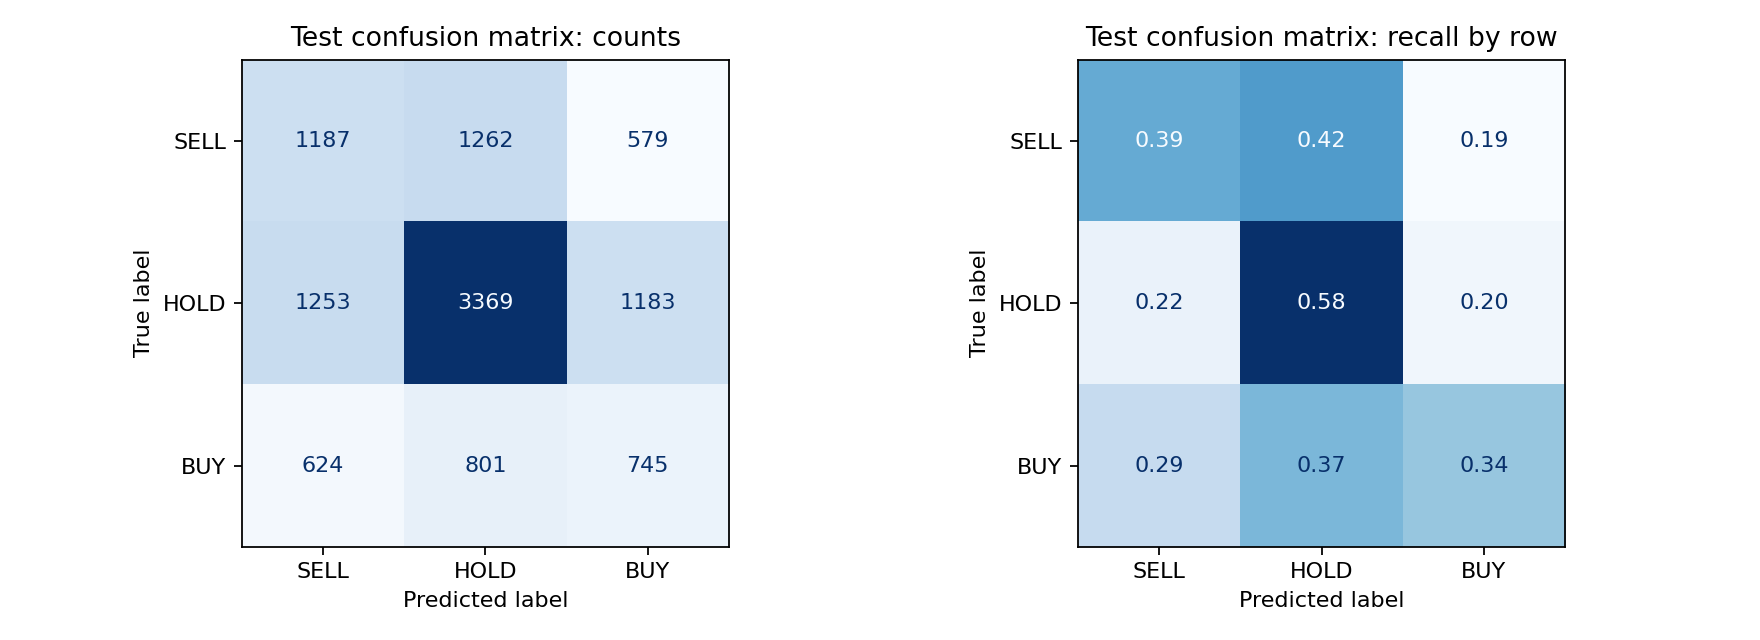

In [5]:
test_pred = predict(model, 'test')
baseline_pred = np.full_like(y['test'], 1)
report = pd.DataFrame(classification_report(y['test'], test_pred, labels=[0,1,2],
    target_names=CLASSES, output_dict=True, zero_division=0)).T
comparison = pd.DataFrame([{'model': name,
    'accuracy': accuracy_score(y['test'], pred),
    'balanced_accuracy': balanced_accuracy_score(y['test'], pred),
    'macro_f1': f1_score(y['test'], pred, labels=[0,1,2], average='macro', zero_division=0),
    'weighted_f1': f1_score(y['test'], pred, labels=[0,1,2], average='weighted', zero_division=0)}
    for name,pred in [('CNN', test_pred), ('Always HOLD', baseline_pred)]])
print('Chosen configuration:', winner)
print(classification_report(y['test'], test_pred, labels=[0,1,2], target_names=CLASSES, digits=4, zero_division=0))
print(comparison.to_string(index=False))
report.to_csv(OUT/'classification_report.csv')
comparison.to_csv(OUT/'baseline_comparison.csv', index=False)
test_details = prices.loc[ends['test'], ['symbol','date','next_date','trade_count','next_return']].copy()
test_details['actual'] = np.asarray(CLASSES)[y['test']]
test_details['predicted'] = np.asarray(CLASSES)[test_pred]
test_details.to_csv(OUT/'test_predictions.csv', index=False)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, norm, title in zip(axes, [None, 'true'], ['Test confusion matrix: counts', 'Test confusion matrix: recall by row']):
    ConfusionMatrixDisplay.from_predictions(y['test'], test_pred, labels=[0,1,2],
        display_labels=CLASSES, normalize=norm, cmap='Blues', ax=ax,
        values_format='d' if norm is None else '.2f', colorbar=False)
    ax.set_title(title)
fig.tight_layout()
fig.savefig(OUT/'confusion_matrix.png', dpi=160)
plt.show()
slice_rows = []
for name, mask in [('Fewer than 20 trades', test_details.trade_count.to_numpy() < 20),
                   ('At least 20 trades', test_details.trade_count.to_numpy() >= 20)]:
    if mask.any():
        slice_rows.append({'slice': name, 'samples': int(mask.sum()),
            'macro_f1': f1_score(y['test'][mask], test_pred[mask], labels=[0,1,2], average='macro', zero_division=0)})
slices = pd.DataFrame(slice_rows)
print('Liquidity slice diagnostics (no further tuning):')
print(slices.to_string(index=False))
slices.to_csv(OUT/'liquidity_slices.csv', index=False)

## 16. Save the model and verify reloading

The checkpoint stores the selected weights, feature order, scaling parameters,
class mapping, window, split boundaries, and experiment configuration. A new
prediction must reproduce the same causal feature calculation and window order.

In [6]:
torch.save({'state_dict': states[winner['name']], 'config': winner,
            'features': FEATURES, 'classes': CLASSES, 'window': WINDOW,
            'scaler_mean': scaler.mean_.tolist(), 'scaler_scale': scaler.scale_.tolist(),
            'validation_start': str(VAL_START.date()), 'test_start': str(TEST_START.date()),
            'seed': SEED}, OUT/'stock_cnn.pt')
saved = torch.load(OUT/'stock_cnn.pt', map_location='cpu', weights_only=True)
reloaded = StockCNN(saved['config']['dropout']).to(DEVICE)
reloaded.load_state_dict(saved['state_dict'])
model.eval()
reloaded.eval()
with torch.no_grad():
    probe = torch.from_numpy(X['test'][:128]).to(DEVICE)
    assert torch.equal(model(probe), reloaded(probe))
print('Checkpoint reload verified: identical logits on 128 held-out inputs.')
environment = {'python': platform.python_version(), 'torch': str(torch.__version__),
               'numpy': np.__version__, 'pandas': pd.__version__, 'polars': pl.__version__,
               'device': str(DEVICE), 'seed': SEED, 'source': signature}
(OUT/'environment.json').write_text(json.dumps(environment, indent=2))

Checkpoint reload verified: identical logits on 128 held-out inputs.


## 17. Discoveries and limitations

The following report text is generated from the executed experiment, so the
reported numbers are measured rather than illustrative. Changing learning rate
and dropout can affect both fitting and validation performance; the best epoch
need not be the last epoch. Test performance is an assessment, not a tuning input.

In [7]:
cnn, hold = comparison.iloc[0], comparison.iloc[1]
reference = experiments.set_index('name').loc['reference', 'val_macro_f1']
discoveries = [
    f"Used {len(y['train']):,} training, {len(y['validation']):,} validation and {len(y['test']):,} test sequences from the week-2 floorsheet.",
    f"Selected {winner['name']} (learning rate {winner['lr']}, dropout {winner['dropout']}) at epoch {int(winner['best_epoch'])}; validation macro F1 {winner['val_macro_f1']:.4f}.",
    f"The selected validation macro F1 differs from the reference by {winner['val_macro_f1']-reference:+.4f}.",
    f"Held-out CNN accuracy {cnn.accuracy:.4f}, balanced accuracy {cnn.balanced_accuracy:.4f}, macro F1 {cnn.macro_f1:.4f}, weighted F1 {cnn.weighted_f1:.4f}.",
    f"Always-HOLD accuracy {hold.accuracy:.4f} and macro F1 {hold.macro_f1:.4f}; CNN differences are {cnn.accuracy-hold.accuracy:+.4f} accuracy and {cnn.macro_f1-hold.macro_f1:+.4f} macro F1.",
]
for name in CLASSES:
    row = report.loc[name]
    discoveries.append(f"{name}: precision {row['precision']:.4f}, recall {row['recall']:.4f}, F1 {row['f1-score']:.4f}, support {int(row['support'])}.")
cm = confusion_matrix(y['test'], test_pred, labels=[0,1,2])
errors = cm.copy()
np.fill_diagonal(errors, 0)
a,b = np.unravel_index(errors.argmax(), errors.shape)
discoveries.append(f"Largest off-diagonal confusion: actual {CLASSES[a]} predicted {CLASSES[b]} ({errors[a,b]:,} samples).")
discoveries.append('Limitations: one seed and one time split; overlapping windows and shared market dates create correlated samples. No confidence intervals or profitability claim. Prices are unadjusted last-trade proxies; corporate actions, sparse trading, changing class balance and irregular session gaps can affect labels and generalization. The 1% threshold and 20-session window were fixed, not tuned. A wider search, repeated seeds and walk-forward validation are future work.')
print('\n\n'.join(discoveries))
(OUT/'discoveries.txt').write_text('\n\n'.join(discoveries), encoding='utf-8')

Used 40,255 training, 10,324 validation and 11,003 test sequences from the week-2 floorsheet.

Selected reference (learning rate 0.001, dropout 0.5) at epoch 3; validation macro F1 0.4038.

The selected validation macro F1 differs from the reference by +0.0000.

Held-out CNN accuracy 0.4818, balanced accuracy 0.4386, macro F1 0.4360, weighted F1 0.4864.

Always-HOLD accuracy 0.5276 and macro F1 0.2302; CNN differences are -0.0458 accuracy and +0.2057 macro F1.

SELL: precision 0.3874, recall 0.3920, F1 0.3897, support 3028.

HOLD: precision 0.6202, recall 0.5804, F1 0.5996, support 5805.

BUY: precision 0.2972, recall 0.3433, F1 0.3186, support 2170.

Largest off-diagonal confusion: actual SELL predicted HOLD (1,262 samples).

Limitations: one seed and one time split; overlapping windows and shared market dates create correlated samples. No confidence intervals or profitability claim. Prices are unadjusted last-trade proxies; corporate actions, sparse trading, changing class balance an

## 18. Report and snapshots

`cnn_results/CNN_Report.html` contains the dataset/method description, actual
hyperparameter and evaluation tables, discoveries, and snapshots of code,
training curves and confusion matrices. Code snapshots are rendered directly
from the executed cells; result figures and table snapshots come from the actual
run, not mock outputs. The notebook also embeds all cell outputs and plots.

## 19. Summary of CNN results

### Implementation and dataset

A **1D CNN was implemented** for the week-2 StockPati floorsheet dataset. Each input contains **nine features over 20 observed trading sessions** for one stock. The classifier predicts SELL, HOLD or BUY from the next observed session's last-trade return, using the fixed -1% and +1% thresholds.

The chronological split produced **40,255 training**, **10,324 validation** and **11,003 test sequences**. Scaling and class weights used training data only, and labels crossing split boundaries were excluded. Hyperparameters and checkpoints were selected using validation macro F1, without tuning on test results.

### Hyperparameter comparison

All four configurations used Adam, batch size 128, weight decay 0.0001 and 10 training epochs.

| Configuration | Learning rate | Dropout | Best epoch | Validation macro F1 |
|---|---:|---:|---:|---:|
| Reference | 0.001 | 0.5 | 3 | **0.4038** |
| Lower learning rate | 0.0003 | 0.5 | 6 | 0.4030 |
| Both changes | 0.0003 | 0.2 | 3 | 0.4001 |
| Lower dropout | 0.001 | 0.2 | 3 | 0.3902 |

The **reference configuration at epoch 3** was selected. Lowering the learning rate delayed the best epoch to 6 but did not improve the best validation score. Lowering dropout to 0.2 also did not improve validation macro F1. Training loss continued to fall while validation scores fluctuated below their earlier peaks, suggesting overfitting. The small difference between the two leading configurations is not evidence of a statistically reliable advantage from this single-seed experiment.

### Held-out test performance

| Metric | CNN | Always-HOLD baseline |
|---|---:|---:|
| Accuracy | 48.18% | **52.76%** |
| Balanced accuracy | **43.86%** | 33.33% |
| Macro F1 | **0.4360** | 0.2302 |
| Weighted F1 | **0.4864** | 0.3644 |

The CNN had **4.58 percentage points lower accuracy**, but **0.2057 higher macro F1** than the always-HOLD baseline. HOLD accounts for 52.76% of the test set, so predicting HOLD every time achieves relatively high accuracy while missing every SELL and BUY example. The CNN recovered some examples from all three classes, although overall performance remained modest.

| Class | Precision | Recall | F1-score | Test support |
|---|---:|---:|---:|---:|
| SELL | 0.3874 | 0.3920 | 0.3897 | 3,028 |
| HOLD | 0.6202 | 0.5804 | 0.5996 | 5,805 |
| BUY | 0.2972 | 0.3433 | 0.3186 | 2,170 |
| Macro average | 0.4349 | 0.4386 | 0.4360 | 11,003 |
| Weighted average | 0.4924 | 0.4818 | 0.4864 | 11,003 |

HOLD was the strongest class by F1, while BUY was the weakest. BUY precision of 0.2972 means fewer than one-third of predicted BUY examples were correct under the experimental label definition.

### Confusion matrix and liquidity findings

Rows below are actual classes; columns are predicted classes.

| Actual / predicted | SELL | HOLD | BUY |
|---|---:|---:|---:|
| SELL | 1,187 | 1,262 | 579 |
| HOLD | 1,253 | 3,369 | 1,183 |
| BUY | 624 | 801 | 745 |

The largest individual error category was **SELL predicted as HOLD: 1,262 examples**. The model also predicted HOLD for 801 actual BUY examples, showing that many directional moves were missed.

For sessions with fewer than 20 trades, test macro F1 was **0.4237** across 2,710 samples. For sessions with at least 20 trades, it was **0.4177** across 8,293 samples. This small descriptive difference does not establish that thinly traded stocks are easier to predict; the groups have different samples and class distributions. Subgroup macro F1 scores do not average directly to overall macro F1.

### Conclusion and limitations

The experiment successfully implemented and evaluated a temporal CNN, compared four hyperparameter settings, and produced the required confusion matrices, precision, recall and F-scores. The selected model improved class-balanced performance over always predicting HOLD, but did **not** beat that baseline on accuracy. Lower learning rate and lower dropout did not improve the best validation result in this run.

These findings are limited to one seed and one chronological split. Overlapping windows and shared market dates create correlated samples. Labels use unadjusted last-trade prices rather than authenticated exchange closes, and irregular trading gaps and corporate actions can affect them. Classification metrics alone do not demonstrate trading profitability. Further work should include repeated seeds, walk-forward validation, stronger baseline classifiers and better price reconciliation before drawing broader conclusions.

The executed outputs, learning curves and report snapshots document the measurements above. The selected model was saved, and reloading was verified to produce identical logits on 128 test inputs. This summary describes the recorded run; update its figures after any new experiment.
